# V16 – Netzwerktechnik Teil 2: Theorie

## 🎯 Lernziele
Nach diesem Notebook kannst du …
- ein **Pandas-DataFrame** aus CSV- und JSON-Dateien laden und die Struktur mit `head`, `shape`, `dtypes`, `describe` inspizieren,
- einzelne Spalten als **Series** ansprechen und mit Aggregations-Methoden (`mean`, `sum`, `max`, `count`) auswerten,
- Daten mit **Boolean-Masken** filtern (`df[df["spalte"] > wert]`),
- mit **`groupby`** Gruppen bilden und pro Gruppe aggregieren (Split-Apply-Combine),
- eine **Series** direkt mit `.plot()` als Linien- oder Balkendiagramm visualisieren,
- erklären, wie eine **HTTP-Anfrage** mit **Statuscodes** (200, 404, 500) funktioniert,
- die Grundidee einer **REST-API** und das Zusammenspiel mit dem Datenformat **JSON** beschreiben,
- eine hartcodierte JSON-Antwort in ein Python-Dictionary parsen und ein DataFrame daraus bauen.

## ⏱️ Zeitbudget
Ca. 45 Minuten in Ruhe durcharbeiten.

## 🧭 TL;DR
Wir verbinden zwei Welten: Auf der einen Seite **Pandas** als Werkzeug, um Tabellen effizient zu analysieren – ein DataFrame ist im Kern eine beschriftete Tabelle, auf der du mit wenigen Zeilen filtern, gruppieren und aggregieren kannst. Auf der anderen Seite die **Netzwerk-Schicht**: Moderne Maschinen liefern ihre Daten heute meistens über eine **HTTP-basierte REST-API** im **JSON-Format**. Wer beides versteht, kann aus einem Maschinen-Endpunkt in wenigen Sekunden einen auswertbaren DataFrame bauen.

## 📦 Voraussetzungen
- [00_python_recap.ipynb](00_python_recap.ipynb)
- V15 (Netzwerk-Grundlagen: OSI/TCP/IP, IP-Adressen, Ports)

## 1. Warum Pandas?

In V09 hast du gesehen, wie man eine CSV-Datei **zeilenweise** liest und eine Liste von Dictionaries aufbaut. Das funktioniert, ist aber für größere Datensätze mühsam: Schon eine einfache Frage wie „Welcher Sensor-Typ hat die höchste mittlere Temperatur?" kostet zehn Zeilen Schleifen-Code. **Pandas** macht solche Auswertungen zu Einzeilern – und im Hintergrund laufen die Operationen in hochoptimiertem C-Code deutlich schneller als reine Python-Schleifen.

Pandas ist nicht magisch: Ein DataFrame ist im Kern ein Wörterbuch aus Spalten-Arrays plus einem Index. Wer die drei Kern-Operationen **Laden**, **Filtern**, **Gruppieren** beherrscht, deckt damit 80 % aller Daten-Fragen im Engineering-Alltag ab.

## 2. DataFrame und Series – die zwei Kernobjekte

Pandas kennt zwei zentrale Datenstrukturen. Eine **Series** ist eine eindimensionale beschriftete Werte-Reihe; du kannst sie dir als eine einzelne Excel-Spalte vorstellen. Ein **DataFrame** ist eine zweidimensionale Tabelle mit mehreren Spalten unterschiedlicher Datentypen; jede Spalte ist intern eine Series. Beide teilen den **Index** (standardmäßig `0, 1, 2, …`), der jede Zeile eindeutig adressiert.

Die folgende Skizze zeigt, wie ein DataFrame aus einer CSV in Spalten-Series zerfällt:

In [1]:
from IPython.display import Markdown, display
with open("diagramme/01_dataframe_struktur.mmd", encoding="utf-8") as f:
    display(Markdown(f"```mermaid\n{f.read()}\n```"))

```mermaid
flowchart TD
    DF["DataFrame<br/>(Tabelle mit Zeilen und Spalten)"]
    DF --> IDX["Index<br/>(0, 1, 2, ...)"]
    DF --> COL1["Spalte 'Sensor_ID'<br/>(Series)"]
    DF --> COL2["Spalte 'Temperatur_C'<br/>(Series)"]
    DF --> COL3["Spalte 'Status'<br/>(Series)"]
    COL1 --> V1["S001, S002, ..."]
    COL2 --> V2["78.5, 45.2, ..."]
    COL3 --> V3["Aktiv, Warnung, ..."]

```

### 2.1 Ein DataFrame aus CSV laden

Die Funktion `pd.read_csv(pfad)` liest eine komma-getrennte Datei ein, nimmt die erste Zeile als Spaltennamen und rät die Datentypen pro Spalte. Das Ergebnis ist ein DataFrame, das du sofort benutzen kannst.

> [!NOTE]
> Die Funktion `read_csv` hat viele optionale Parameter (`sep`, `decimal`, `encoding`, `parse_dates`), die du brauchst, wenn die Datei nicht UTF-8 / Komma-Standard ist. Für die V16-Testdaten reichen die Defaults.

In [2]:
import pandas as pd

df = pd.read_csv("sensoren_daten.csv")
print("Spalten:", list(df.columns))
print("Form:", df.shape)
df.head(3)

Spalten: ['Sensor_ID', 'Sensor_Name', 'Typ', 'Position', 'Temperatur_C', 'Vibration_mm_s', 'Druck_bar', 'Letztwartung', 'Status']
Form: (15, 9)


,Sensor_ID,Sensor_Name,Typ,Position,Temperatur_C,Vibration_mm_s,Druck_bar,Letztwartung,Status
0,S001,Temp-Sensor-01,Temperatur,Linie_A_Spindel,78.5,0.15,5.2,2024-11-15,Aktiv
1,S002,Vib-Sensor-01,Vibration,Linie_A_Lager,45.2,2.35,4.8,2024-10-22,Aktiv
2,S003,Druck-Sensor-01,Druck,Linie_A_Hydraulik,23.1,0.08,152.3,2024-12-01,Aktiv


### 2.2 Struktur inspizieren – `dtypes`, `describe`, `info`

Bevor du rechnest, schaust du dir das DataFrame an: Welche Spalten gibt es, welchen Datentyp haben sie, wie sehen typische Werte aus? Diese drei Methoden sind dein Standard-Repertoire.

In [3]:
print(df.dtypes)

Sensor_ID             str
Sensor_Name           str
Typ                   str
Position              str
Temperatur_C      float64
Vibration_mm_s    float64
Druck_bar         float64
Letztwartung          str
Status                str
dtype: object


In [4]:
df.describe()

,Temperatur_C,Vibration_mm_s,Druck_bar
count,15.000000,15.000000,15.000000
mean,53.700000,1.308000,50.726667
std,27.364811,1.939765,67.842048
min,19.500000,0.060000,4.700000
25%,30.050000,0.105000,5.150000
50%,48.300000,0.220000,5.800000
75%,71.800000,1.935000,120.350000
max,105.200000,5.920000,165.800000


`describe()` liefert **nur für numerische Spalten** Statistiken (Anzahl, Mittelwert, Std.-Abweichung, Min/Max, Quartile). Das ist der schnellste Weg, auffällige Messwerte zu erkennen: Wenn `max` deutlich über `75 %` liegt, hast du wahrscheinlich Ausreißer.

## 3. Spaltenzugriff und Aggregation

Eine einzelne Spalte sprichst du mit `df["spaltenname"]` an – das Ergebnis ist eine Series. Auf dieser kannst du direkt aggregieren: `.mean()`, `.sum()`, `.max()`, `.min()`, `.count()`, `.std()`. Diese Methoden ignorieren fehlende Werte (`NaN`) standardmäßig, was in realen Messreihen der Normalfall ist.

In [5]:
print("Mittlere Temperatur:", df["Temperatur_C"].mean())
print("Max. Vibration:   ", df["Vibration_mm_s"].max())
print("Summe Druck:      ", df["Druck_bar"].sum())
print("Anzahl Sensoren:  ", df["Sensor_ID"].count())

Mittlere Temperatur: 53.699999999999996
Max. Vibration:    5.92
Summe Druck:       760.9000000000001
Anzahl Sensoren:   15


### 3.1 Mehrere Spalten gleichzeitig

Mit einer **Liste von Spaltennamen** holst du dir mehrere Spalten als Sub-DataFrame. Das ist nützlich, um die Sicht vor weiteren Operationen gezielt zu verkleinern.

In [6]:
df[["Sensor_ID", "Temperatur_C", "Status"]].head()

,Sensor_ID,Temperatur_C,Status
0,S001,78.5,Aktiv
1,S002,45.2,Aktiv
2,S003,23.1,Aktiv
3,S004,92.3,Warnung
4,S005,52.8,Kritisch


## 4. Filtern mit Boolean-Masken

Eine **Boolean-Maske** ist eine Series aus `True`/`False`-Werten, mit der du ein DataFrame indizieren kannst. Ein Ausdruck wie `df["Temperatur_C"] > 80` liefert genau solche Maske zurück. Setzt du diese in eckige Klammern des DataFrames, behältst du nur die Zeilen, für die die Maske `True` ist.

> [!NOTE]
> Eine **Boolean-Maske** ist ein Filter: Für jede Zeile wird eine Bedingung ausgewertet und das Ergebnis (`True`/`False`) merkt sich Pandas. Nur Zeilen mit `True` bleiben im Ergebnis übrig.

In [7]:
heiss = df[df["Temperatur_C"] > 80]
print(f"{len(heiss)} Sensoren mit Temperatur > 80 °C:")
heiss[["Sensor_ID", "Temperatur_C", "Status"]]

3 Sensoren mit Temperatur > 80 °C:


,Sensor_ID,Temperatur_C,Status
3,S004,92.3,Warnung
9,S010,88.7,Warnung
12,S013,105.2,Kritisch


### 4.1 Kombinierte Bedingungen

Mit `&` (und), `|` (oder) und `~` (nicht) verknüpfst du mehrere Masken. **Achtung:** Jede Teilbedingung muss wegen der Operator-Vorrangregeln in Klammern stehen.

In [8]:
kritisch = df[(df["Status"] == "Kritisch") | (df["Vibration_mm_s"] > 4.0)]
kritisch[["Sensor_ID", "Status", "Vibration_mm_s"]]

,Sensor_ID,Status,Vibration_mm_s
4,S005,Kritisch,4.82
12,S013,Kritisch,0.35
13,S014,Kritisch,5.92


> [!WARNING]
> Verwende für Masken **nicht** `and`/`or` – das funktioniert nur für skalare Wahrheitswerte, nicht für Series. Pandas wirft dann einen `ValueError`. Immer `&`, `|`, `~` mit Klammern pro Teil-Bedingung.

## 5. Gruppieren mit `groupby` – Split-Apply-Combine

`groupby` ist das mächtigste Werkzeug von Pandas. Die Idee heißt **Split-Apply-Combine**: Das DataFrame wird nach einer Schlüsselspalte in Gruppen geteilt, auf jeder Gruppe wird dieselbe Aggregation ausgeführt, und die Ergebnisse werden wieder zu einem Objekt zusammengeführt.

Das klassische Beispiel: Du willst pro Sensor-Typ den mittleren Temperatur-Wert. Statt für jeden Typ eine Boolean-Maske anzulegen, schreibst du eine Zeile.

In [9]:
from IPython.display import Markdown, display
with open("diagramme/02_groupby_flow.mmd", encoding="utf-8") as f:
    display(Markdown(f"```mermaid\n{f.read()}\n```"))

```mermaid
flowchart LR
    IN["DataFrame<br/>(alle Zeilen)"] --> SPLIT["Split<br/>(nach Schluesselspalte<br/>z.B. Kategorie)"]
    SPLIT --> G1["Gruppe A"]
    SPLIT --> G2["Gruppe B"]
    SPLIT --> G3["Gruppe C"]
    G1 --> APPLY["Apply<br/>(Aggregation<br/>z.B. mean, sum)"]
    G2 --> APPLY
    G3 --> APPLY
    APPLY --> COMB["Combine<br/>(Series mit<br/>einem Wert pro Gruppe)"]

```

In [10]:
df.groupby("Typ")["Temperatur_C"].mean()

Typ
Druck         25.82
Temperatur    85.96
Vibration     49.32
Name: Temperatur_C, dtype: float64

Das Ergebnis ist eine Series mit den Sensor-Typen als Index und dem Mittelwert als Werte. Du kannst sie weiterverarbeiten wie jede andere Series: Maximum finden, sortieren, plotten.

### 5.1 `idxmax` – die Gruppe mit dem höchsten Wert

`.idxmax()` liefert den **Index**, an dem der höchste Wert steht – also den Gruppennamen. Das ist das Standard-Werkzeug für Fragen wie „Welche Kategorie ist am teuersten?" oder „Welche Linie produziert am meisten?".

In [11]:
mittel_pro_typ = df.groupby("Typ")["Temperatur_C"].mean()
print("Höchster Mittelwert:", mittel_pro_typ.idxmax(), "→", mittel_pro_typ.max())

Höchster Mittelwert: Temperatur → 85.96000000000001


### 5.2 Zählen pro Gruppe

Für Fragen wie „Wie viele Sensoren pro Status?" nimmst du `size()` oder `value_counts()`. Beide sind mit einer Zeile erledigt.

In [12]:
print(df["Status"].value_counts())

Status
Aktiv       9
Warnung     3
Kritisch    3
Name: count, dtype: int64


## 6. Einfache Plots mit `.plot()`

Jede Series und jedes DataFrame hat eine `.plot()`-Methode, die direkt auf Matplotlib aufsetzt. Ohne weitere Argumente gibt es ein Liniendiagramm; mit `kind="bar"` oder `kind="hist"` bekommst du Balken oder Histogramm. In Notebooks wird die Grafik automatisch inline angezeigt.

> [!TIP]
> Für einen schnellen Überblick reicht `df["spalte"].plot()`. Erst wenn du Achsenbeschriftungen, Titel oder mehrere Layer willst, lohnt der Griff zu Matplotlib direkt.

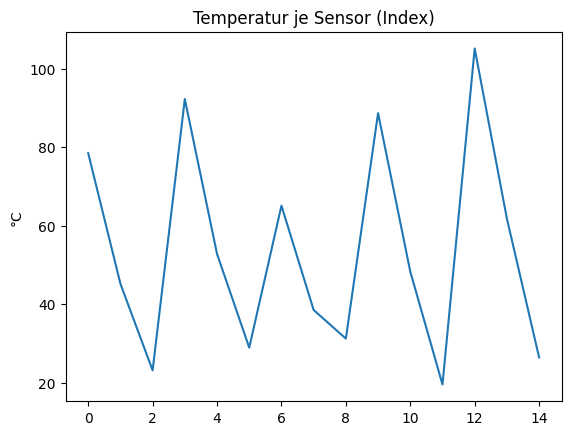

In [13]:
import matplotlib.pyplot as plt

df["Temperatur_C"].plot(title="Temperatur je Sensor (Index)")
plt.ylabel("°C")
plt.show()

## 7. JSON laden – `read_json` und `json.load`

Pandas kann JSON direkt lesen, wenn die Struktur bereits eine Liste von flachen Objekten ist. Bei verschachtelten JSON-Dateien (wie unseren Wartungsaufträgen mit einer Root-Ebene `"wartungsauftraege": [...]`) ist der sicherste Weg der Zwei-Schritt: erst `json.load`, dann `pd.DataFrame(liste)`.

In [14]:
import json

with open("wartungsauftraege.json", encoding="utf-8") as f:
    daten = json.load(f)

df_w = pd.DataFrame(daten["wartungsauftraege"])
print("Form:", df_w.shape)
df_w[["auftrag_id", "typ", "prioritaet", "kosten_euro", "status"]].head()

Form: (10, 11)


,auftrag_id,typ,prioritaet,kosten_euro,status
0,W2024-001,Präventiv,Mittel,580.0,Geplant
1,W2024-002,Störung,Hoch,1250.0,In Bearbeitung
2,W2024-003,Präventiv,Niedrig,420.0,Geplant
3,W2024-004,Inspektion,Mittel,320.0,Abgeschlossen
4,W2024-005,Störung,Kritisch,2100.0,Abgeschlossen


## 8. XML in ein DataFrame überführen

Für XML gibt es keine so elegante Einzeiler-Funktion, weil XML freier strukturiert ist als JSON. Der Standard-Ansatz: Mit `xml.etree.ElementTree` durch den Baum iterieren, pro Eintrag ein Dictionary bauen, die Liste der Dictionaries an `pd.DataFrame(...)` übergeben.

Das folgende Muster brauchst du in A4:

In [15]:
import xml.etree.ElementTree as ET

baum = ET.parse("produktionsplanung.xml")
zeilen = []
for linie in baum.findall(".//produktionslinie"):
    linie_id = linie.get("id")
    for auftrag in linie.findall("auftrag"):
        zeilen.append({
            "linie_id": linie_id,
            "auftrag_id": auftrag.get("auftrag_id"),
            "stueckzahl_produziert": int(auftrag.findtext("stueckzahl_produziert")),
            "status": auftrag.findtext("status"),
        })

df_x = pd.DataFrame(zeilen)
df_x

,linie_id,auftrag_id,stueckzahl_produziert,status
0,Linie_A,A-2024-1201,148,Abgeschlossen
1,Linie_A,A-2024-1202,285,In Bearbeitung
2,Linie_B,B-2024-1203,487,Abgeschlossen
3,Linie_B,B-2024-1204,195,In Bearbeitung
4,Linie_C,C-2024-1205,82,Abgeschlossen
5,Linie_C,C-2024-1206,0,Geplant


## 9. Netzwerk-Teil: HTTP, Statuscodes, REST

In V15 hast du die Schichten OSI/TCP/IP kennengelernt. Auf der **Anwendungsschicht** läuft heute fast jede Maschinen-zu-Maschinen-Kommunikation über das **Hypertext Transfer Protocol (HTTP)**. Ein Client (dein Python-Skript) sendet eine **Anfrage** (Request) an einen Server und bekommt eine **Antwort** (Response) zurück. Jede Antwort trägt einen **Statuscode**, der in einer Zahl ausdrückt, ob alles geklappt hat.

> [!NOTE]
> Ein **HTTP-Statuscode** ist eine dreistellige Zahl, die den Ausgang der Anfrage beschreibt. Die erste Ziffer kategorisiert grob: 2xx Erfolg, 3xx Umleitung, 4xx Client-Fehler, 5xx Server-Fehler.

### 9.1 Die drei wichtigsten Codes

| Code | Bedeutung | Wer ist schuld? |
|---|---|---|
| **200 OK** | Alles gut, Daten im Body | niemand |
| **404 Not Found** | Ressource gibt's nicht | Client (falsche URL) |
| **500 Internal Server Error** | Der Server hat Mist gebaut | Server |

Wer eine API anspricht, prüft als erstes den Code und erst dann den Body. Ein Body mit HTML-Fehlermeldung hilft keinem Auswerte-Skript.

In [16]:
from IPython.display import Markdown, display
with open("diagramme/03_http_request_response.mmd", encoding="utf-8") as f:
    display(Markdown(f"```mermaid\n{f.read()}\n```"))

```mermaid
sequenceDiagram
    participant Client as Client<br/>(Python-Skript)
    participant Server as Server<br/>(z.B. api.example.com)
    Client->>Server: HTTP GET /api/sensors
    Note over Client,Server: Anfrage mit Header<br/>Accept: application/json
    Server-->>Client: 200 OK + JSON-Body
    Note over Client,Server: Antwort mit Statuscode<br/>und JSON-Daten
    Client->>Server: HTTP GET /api/unknown
    Server-->>Client: 404 Not Found
    Client->>Server: HTTP GET /api/broken
    Server-->>Client: 500 Internal Server Error

```

### 9.2 REST-APIs und Endpunkte

**REST** (REpresentational State Transfer) ist kein Protokoll, sondern ein **Architekturstil**, nach dem viele moderne Web-APIs aufgebaut sind. Die Kernidee: Jede **Ressource** (Sensoren, Aufträge, Produkte) bekommt eine eindeutige URL, einen sogenannten **Endpunkt**, und die **HTTP-Methode** entscheidet, was passiert: `GET` liest, `POST` legt an, `PUT` ersetzt, `DELETE` löscht.

Für eine fiktive Fabrik-API könnten die Endpunkte so aussehen:

In [17]:
from IPython.display import Markdown, display
with open("diagramme/04_rest_endpoints.mmd", encoding="utf-8") as f:
    display(Markdown(f"```mermaid\n{f.read()}\n```"))

```mermaid
flowchart TD
    API(["REST API<br/>https://fabrik.example.com"])
    API --> S["/api/sensors<br/>(Sensor-Messwerte)"]
    API --> O["/api/orders<br/>(Wartungsauftraege)"]
    API --> P["/api/planning<br/>(Produktionsplanung)"]
    S --> SG["GET: Liste aller Sensoren"]
    S --> SD["GET /api/sensors/S001<br/>(einzelner Sensor)"]
    O --> OG["GET: alle Auftraege"]
    O --> OP["POST: neuer Auftrag"]
    P --> PG["GET: aktuelle Woche"]

```

### 9.3 `requests.get` – konzeptionell

Die Python-Bibliothek **`requests`** macht HTTP-Aufrufe zu einem Einzeiler. Wir führen sie in diesem Notebook **bewusst nicht live** aus (keine Netzwerk-Verbindung nötig), du sollst aber das Muster erkennen:

```python
# Nur konzeptionell – wird hier nicht ausgeführt!
# import requests
# antwort = requests.get("https://fabrik.example.com/api/sensors")
# if antwort.status_code == 200:
#     daten = antwort.json()   # JSON → Python-Liste/Dict
#     df = pd.DataFrame(daten)
# else:
#     print("Fehler:", antwort.status_code)
```

Der wichtige Punkt: Das Ergebnis von `.json()` ist ein gewöhnliches Python-Dictionary oder eine Liste davon. Ab da ist alles Pandas-Routine.

### 9.4 Eine hartcodierte JSON-Antwort parsen

Statt einen echten Server zu fragen, simulieren wir die Antwort. Das Ergebnis eines `requests.get(...).json()`-Aufrufs wäre ein Python-Objekt wie dieses – und genau damit können wir weiterarbeiten, als wäre es live geholt worden.

In [18]:
# Simulierte API-Antwort (so würde sie von requests.get(...).json() kommen)
antwort = {
    "status": 200,
    "sensors": [
        {"id": "S001", "typ": "Temperatur", "wert": 78.5},
        {"id": "S002", "typ": "Vibration",  "wert": 2.35},
        {"id": "S003", "typ": "Druck",      "wert": 152.3},
    ],
}

df_api = pd.DataFrame(antwort["sensors"])
df_api

,id,typ,wert
0,S001,Temperatur,78.50
1,S002,Vibration,2.35
2,S003,Druck,152.30


## 10. Industrie-Beispiel: OPC-UA-Wertstrom → CSV → Pandas

In einer typischen Produktionshalle läuft folgender Datenpfad: Sensoren melden ihre Werte an einen **OPC-UA-Server**, ein **Historian** (Archiv-Dienst) speichert sie als CSV- oder Parquet-Datei, und das Engineering-Team wertet die Datei offline mit Pandas aus. Vorteil: Die Auswertung belastet den OPC-UA-Server nicht und ist beliebig reproduzierbar.

Die Tabelle im Historian sieht üblicherweise so aus:

| Zeitstempel | NodeId | Wert | Qualität |
|---|---|---|---|
| 2024-12-09 08:00:01 | ns=2;s=Spindel.Temp | 78.3 | Good |
| 2024-12-09 08:00:02 | ns=2;s=Spindel.Drehzahl | 8500 | Good |
| … | … | … | … |

Mit Pandas kannst du in drei Zeilen „Wie hoch ist die mittlere Spindel-Temperatur pro Stunde?" beantworten: `read_csv`, Boolean-Maske auf `NodeId`, `groupby` auf die Stunde, `mean` auf `Wert`. Genau diese Schritte übst du in Praxis und Aufgaben.

## 11. Selbst-Check – aufklappbar

<details>
<summary><b>F1:</b> Was ist der Unterschied zwischen einer Series und einem DataFrame?</summary>

Eine **Series** ist eindimensional (eine Spalte mit Werten plus Index). Ein **DataFrame** ist zweidimensional (mehrere Spalten unterschiedlicher Typen mit gemeinsamem Index). Technisch ist jede Spalte eines DataFrames eine Series.
</details>

<details>
<summary><b>F2:</b> Wie filterst du alle Zeilen, in denen `Temperatur_C` größer als 50 ist?</summary>

`df[df["Temperatur_C"] > 50]`
</details>

<details>
<summary><b>F3:</b> Welche drei Schritte sind das Split-Apply-Combine-Muster von groupby?</summary>

1. **Split**: Das DataFrame wird nach einer Schlüsselspalte in Gruppen geteilt.
2. **Apply**: Auf jede Gruppe wird dieselbe Aggregation angewendet (z. B. `mean`, `sum`).
3. **Combine**: Die Ergebnisse werden zu einer neuen Series/einem neuen DataFrame zusammengefügt.
</details>

<details>
<summary><b>F4:</b> Welchen HTTP-Statuscode erwartest du bei einer falsch geschriebenen URL?</summary>

**404 Not Found**. Der Server existiert, aber die angegebene Ressource gibt es dort nicht.
</details>

<details>
<summary><b>F5:</b> Warum nicht `and`/`or` für Boolean-Masken in Pandas?</summary>

`and`/`or` erwarten **skalare** Wahrheitswerte. Eine Series ist mehrwertig – Pandas weiß nicht, ob sie als Ganzes wahr ist, und wirft einen `ValueError`. Für elementweise Kombination nutzt du `&`, `|`, `~` und klammerst jede Teilbedingung.
</details>

<details>
<summary><b>F6:</b> Was liefert `df.groupby("Kategorie")["Preis"].mean().idxmax()`?</summary>

Den **Namen der Kategorie** mit dem höchsten Durchschnittspreis. `idxmax` gibt den Index zurück, an dem das Maximum steht.
</details>

<details>
<summary><b>F7:</b> Warum rufen wir `requests.get` in diesem Kurs nicht live auf?</summary>

Weil die Übungen **offline** durchlaufen sollen (keine Abhängigkeit von externen Servern, reproduzierbar). Das Prinzip bleibt identisch: Eine REST-Antwort ist am Ende nur ein Python-Dict/eine Liste – und genau damit arbeiten wir aus den mitgelieferten Testdaten.
</details>

<details>
<summary><b>F8:</b> Du hast eine verschachtelte JSON-Datei mit einer Root-Ebene. Wie kommst du zum DataFrame?</summary>

`json.load` liefert das Python-Objekt. Die relevante Liste adressierst du mit dem Root-Key (`daten["wartungsauftraege"]`) und übergibst sie an `pd.DataFrame(...)`.
</details>

## ✅ Zusammenfassung
- Ein **DataFrame** ist eine Tabelle, eine **Series** eine einzelne Spalte.
- **Laden** über `pd.read_csv`, `pd.read_json`, oder `json.load` + `pd.DataFrame(...)`.
- **Filtern** mit Boolean-Masken (`&`, `|`, `~`, immer klammern).
- **Gruppieren** mit `groupby("spalte")["zielspalte"].aggregation()` – Split-Apply-Combine.
- **Plotten** mit `.plot()` direkt auf Series/DataFrame.
- **HTTP** nutzt Statuscodes: 200 OK, 404 Not Found, 500 Server-Fehler.
- **REST-APIs** liefern meist JSON – `.json()` → Python-Objekt → `pd.DataFrame`.

## ➡️ Nächster Schritt
Weiter mit [02_praxis.ipynb](02_praxis.ipynb) – Hands-on mit `sensoren_daten.csv`.